Load the main tracking CSV

In [1]:
import pandas as pd

tracking_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\detailed_tracking_info.csv")
shape_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\consistent_shape_summary.csv")
trajectories_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\cell_trajectories.csv")
boundaries_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\consistent_cell_boundaries.csv")


cells per frame

timepoint
0      10
1      13
2      11
3      12
4      12
       ..
116    12
117    12
118    12
119    11
120    10
Name: global_id, Length: 121, dtype: int64


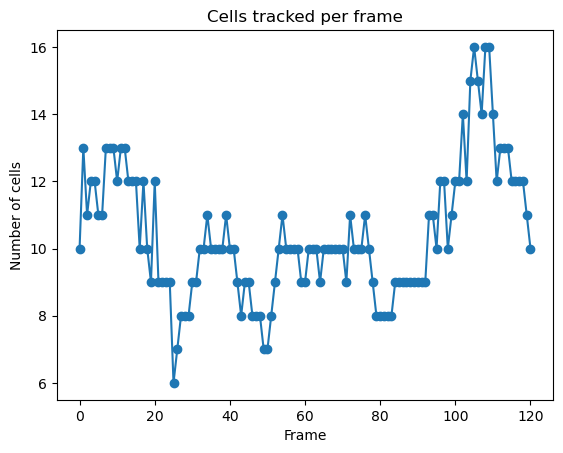

In [2]:
import matplotlib.pyplot as plt

cells_per_frame = tracking_df.groupby('timepoint')['global_id'].nunique()
print(cells_per_frame)

cells_per_frame.plot(marker='o')
plt.xlabel("Frame")
plt.ylabel("Number of cells")
plt.title("Cells tracked per frame")
plt.show()

Cell lifespans

In [3]:
lifespans = tracking_df.groupby('global_id')['timepoint'].agg(['min','max','count'])
lifespans['lifespan'] = lifespans['max'] - lifespans['min'] + 1
print(lifespans.describe())

              min         max       count    lifespan
count   50.000000   50.000000   50.000000   50.000000
mean    50.240000   75.340000   25.220000   26.100000
std     41.816196   40.884411   31.503346   32.088685
min      0.000000    3.000000    1.000000    1.000000
25%      1.750000   42.500000    3.000000    3.250000
50%     52.500000   77.500000   15.500000   15.500000
75%     95.250000  113.000000   31.750000   32.500000
max    112.000000  120.000000  120.000000  120.000000


Trajectory distances

   cell_id  total_distance_um  avg_speed_um_per_frame
0        1         253.654375                2.438984
1        2          88.841815                2.115281
2        3          42.995653                1.869376
3        5          12.304363                2.050727
4        6         209.278671                1.758644


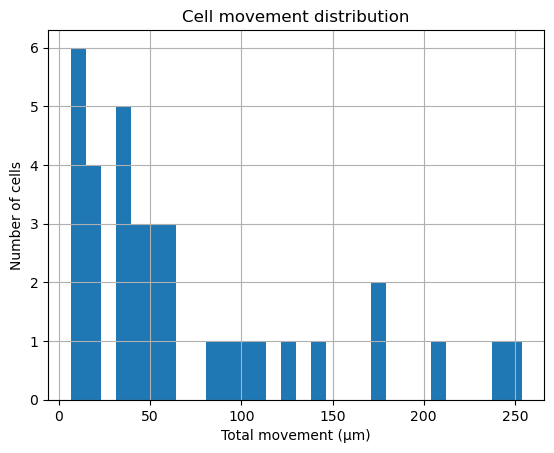

In [4]:
print(trajectories_df[['cell_id','total_distance_um','avg_speed_um_per_frame']].head())

trajectories_df['total_distance_um'].hist(bins=30)
plt.xlabel("Total movement (µm)")
plt.ylabel("Number of cells")
plt.title("Cell movement distribution")
plt.show()

Shape metrics sanity

In [5]:
print(shape_df[['area_um2','perimeter_um','eccentricity','solidity']].describe())

          area_um2  perimeter_um  eccentricity     solidity
count  1261.000000   1261.000000   1261.000000  1261.000000
mean   1911.523761    166.027977      0.617077     0.978307
std     789.047160     38.837511      0.156726     0.019326
min     159.185374     51.872396      0.124101     0.845411
25%    1309.200753    140.760685      0.512884     0.975491
50%    1943.915025    170.192650      0.637124     0.985239
75%    2506.807636    193.051965      0.738659     0.989415
max    4051.166407    277.923235      0.923731     0.993702


trajectory plot

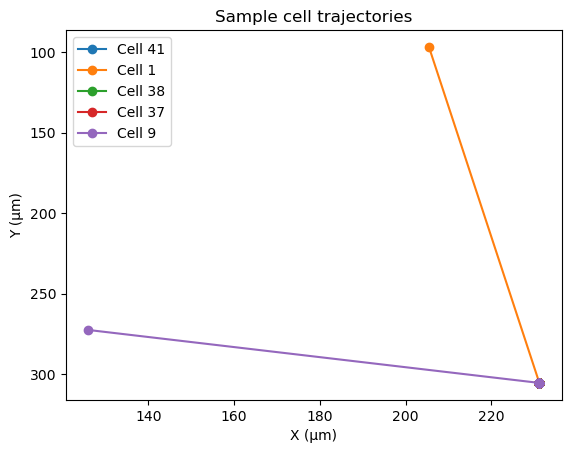

In [6]:
sample_cells = trajectories_df['cell_id'].sample(5)
for cid in sample_cells:
    cell_data = tracking_df[tracking_df['global_id']==cid].sort_values('timepoint')
    plt.plot(cell_data['centroid_x_um'], cell_data['centroid_y_um'], marker='o', label=f'Cell {cid}')

plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")
plt.title("Sample cell trajectories")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

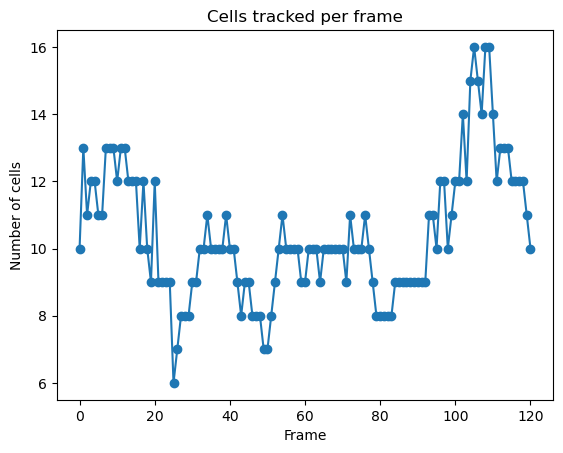

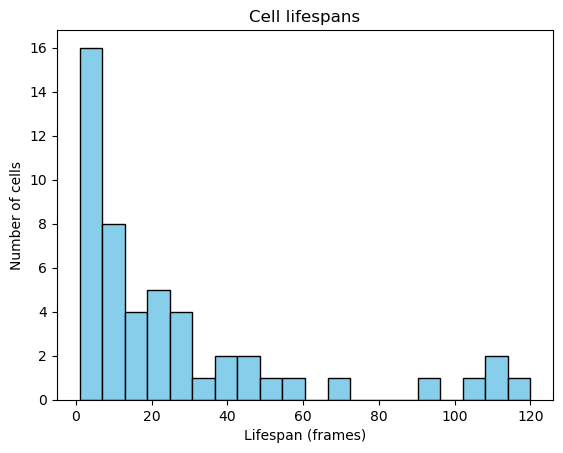

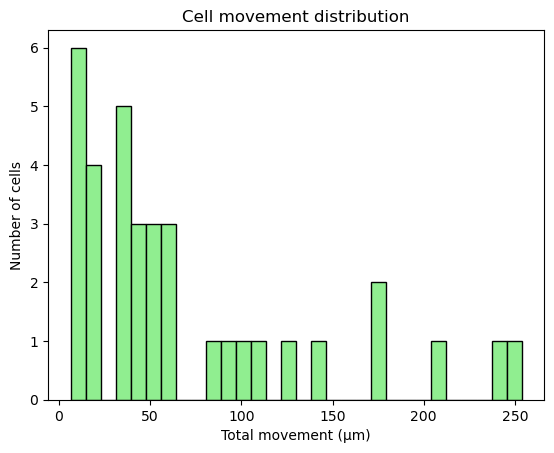

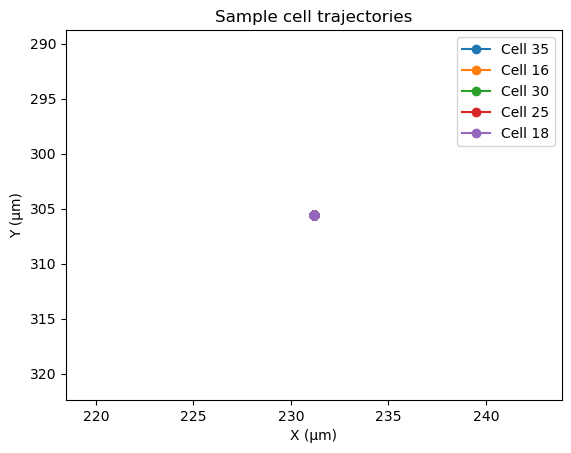

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSVs
tracking_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\detailed_tracking_info.csv")
shape_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\consistent_shape_summary.csv")
trajectories_df = pd.read_csv(r"F:\z_vir\_GitHub\cellpose2coordinates\pixel_version\cell_trajectories.csv")

# 1️⃣ Cells per frame
cells_per_frame = tracking_df.groupby('timepoint')['global_id'].nunique()
fig = cells_per_frame.plot(marker='o', title='Cells tracked per frame')
plt.xlabel("Frame")
plt.ylabel("Number of cells")
plt.savefig("cells_per_frame.png")
plt.show()

# 2️⃣ Cell lifespans
lifespans = tracking_df.groupby('global_id')['timepoint'].agg(['min','max'])
lifespans['lifespan'] = lifespans['max'] - lifespans['min'] + 1
plt.figure()
plt.hist(lifespans['lifespan'], bins=20, color='skyblue', edgecolor='k')
plt.xlabel("Lifespan (frames)")
plt.ylabel("Number of cells")
plt.title("Cell lifespans")
plt.savefig("cell_lifespans.png")
plt.show()

# 3️⃣ Movement distances
plt.figure()
plt.hist(trajectories_df['total_distance_um'], bins=30, color='lightgreen', edgecolor='k')
plt.xlabel("Total movement (µm)")
plt.ylabel("Number of cells")
plt.title("Cell movement distribution")
plt.savefig("movement_distances.png")
plt.show()

# 4️⃣ Sample trajectories
plt.figure()
sample_cells = trajectories_df['cell_id'].sample(min(5, len(trajectories_df)), random_state=42)
for cid in sample_cells:
    cell_data = tracking_df[tracking_df['global_id']==cid].sort_values('timepoint')
    plt.plot(cell_data['centroid_x_um'], cell_data['centroid_y_um'], marker='o', label=f'Cell {cid}')
plt.xlabel("X (µm)")
plt.ylabel("Y (µm)")
plt.title("Sample cell trajectories")
plt.gca().invert_yaxis()
plt.legend()
plt.savefig("sample_trajectories.png")
plt.show()